In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import stan
# import nest_asyncio
# nest_asyncio.apply()

In [2]:
df = pd.read_csv('/Users/vivekhsridhar/Library/Mobile Documents/com~apple~CloudDocs/Documents/Code/territory_geometry/processed_data/stability_ALL.csv')
df.head()

,lek_id,date_prev,date_now,centroid_shift,mode_shift,nn_cross_median,nn_cross_mean,nn_cross_cv
0,TalChhapar_TC,2012-10-01,2014-02-01,14.345197,25.195197,3.033985,6.864682,1.341986
1,TalChhapar_TC,2014-02-01,2015-11-01,19.180344,44.531731,5.317716,9.612448,1.142450
2,TalChhapar_TC,2015-11-01,2015-12-01,5.288125,33.362349,1.149035,4.630130,1.725009
3,TalChhapar_TC,2015-12-01,2018-01-01,62.661803,27.941469,10.504549,24.557366,1.565752
4,TalChhapar_TC,2018-01-01,2018-11-01,30.013742,65.168473,6.443491,12.524062,1.367217


In [3]:
# Ensure date column is parsed correctly
df['date_now'] = pd.to_datetime(df['date_now'])

In [7]:
t0 = df['date_now'].min()
df['time_years'] = (df['date_now'] - t0).dt.days / 365.25

time = df['time_years']  # or time_months if you prefer
df['time_std'] = (time - time.mean()) / time.std()

In [4]:
crossyear_nnd = """
data {
    int<lower=1> N;
    vector[N] t;
    vector<lower=0>[N] y;
}
parameters {
    real alpha;
    real beta;
    real<lower=0> sigma;
}
transformed parameters {
}
model {
    y ~ normal(alpha + beta * t, sigma);
}
"""

data = {
    'N': len(df), 
    't': np.asarray(df.nn_cross_mean), 
    'y': np.asarray(df.nn_cross_median)
}

posterior = stan.build(crossyear_nnd, data=data)
fit = posterior.sample(num_chains=4, num_samples=1000)

Building: 0.1s
Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.8s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.3s
Building: 1.4s
Building: 1.5s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.3s
Building: 4.4s
Building: 4.5s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 7.0s
Building: 

In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_ccdf_log.hpp:5,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob.hpp:331,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/vivek/.cache/httpstan/4.13.0/models/y4p2vehi/model_y4p2vehi.cpp:2:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_lccdf.hpp: In function ‘stan::return_typ

Building: 8.5s
Building: 8.6s
Building: 8.7s
Building: 8.8s
Building: 8.9s
Building: 9.0s
Building: 9.1s
Building: 9.2s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:10:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [with Traits = tbb::interface5::concurrent_unordered_map_traits<std::pair<std::basic_string<char>, std::thread::id>, stan::math::profile_info, tbb::interface5::internal::hash_compare<std::pair<std::basic_string<char>, std::thread::id>, stan::math::internal::hash_p

Building: 9.3s
Building: 9.4s
Building: 9.5s
Building: 9.6s
Building: 9.7s
Building: 9.8s
Building: 9.9s
Building: 10.0s
Building: 10.1s
Building: 10.2s
Building: 10.3s
Building: 10.5s
Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building: 11.7s
Building: 11.8s
Building: 11.9s
Building: 12.0s
Building: 12.1s
Building: 12.3s
Building: 12.4s
Building: 12.5s
Building: 12.6s
Building: 12.7s
Building: 12.8s
Building: 12.9s
Building: 13.0s
Building: 13.1s
Building: 13.2s
Building: 13.3s
Building: 13.4s
Building: 13.5s
Building: 13.6s
Building: 13.7s
Building: 13.8s
Building: 13.9s
Building: 14.0s
Building: 14.1s
Building: 14.2s
Building: 14.3s
Building: 14.4s
Building: 14.5s
Building: 14.6s
Building: 14.7s
Building: 14.8s
Building: 14.9s
Building: 15.1s
Building: 15.2s
Building: 15.3s
Building: 15.4s
Building: 15.5s
Building: 15.6s
Building: 15.7s
Building: 15.8s

Building: 17.5s, done.
Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 2.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.21 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.3 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would t

array([-4.83473482, -3.50777138, -2.14759525, -0.83379407,  0.46872305,
        1.75903606,  3.0217093 ,  4.32714979,  5.57271351,  6.83140835,
        8.10872815,  9.33523296, 10.5625175 , 11.74579311, 12.9588745 ,
       14.1287441 , 15.30056694, 16.43759884, 17.56110848, 18.62040927,
       19.70488048, 20.79580446, 21.86294228, 22.89617822, 23.94061411,
       25.01406892, 26.05044912, 27.05398575, 28.0748353 , 29.08410804,
       30.1142868 , 31.12848516, 32.12184533, 33.16500694, 34.14708518,
       35.1887041 , 36.19489373, 37.20179343, 38.2132043 , 39.23394507,
       40.23620072, 41.24462503, 42.23886186, 43.24442918, 44.23250792,
       45.21889118, 46.20684038, 47.1899078 , 48.15310472, 49.14827381])

In [22]:
x.shape

(50,)

In [11]:
x = np.linspace(0,100)

a = fit['alpha'].reshape(-1)
b = fit['beta'].reshape(-1)

y = a + b * x[:,None]

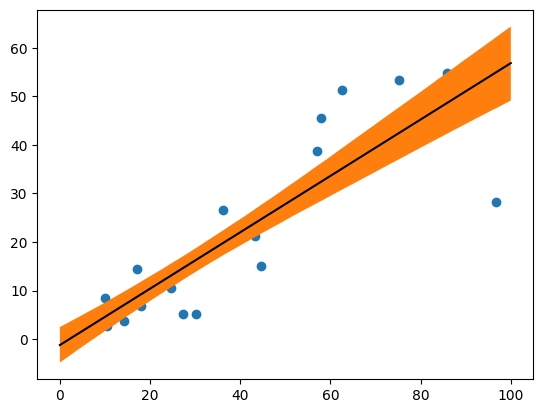

In [30]:
plt.scatter(df['nn_cross_mean'], df['nn_cross_median'])
plt.plot(x, y.mean(axis=1), color='black')
plt.fill_between(x, np.quantile(y, 0.05, axis=1), np.quantile(y, 0.95, axis=1), color='black', alpha=0.4)
plt.show()